In [1]:
library(Seurat)
library(tidyverse)
library(scales)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘scales’


The following object is masked from ‘package:purrr’:

    discard


The following object is masked from ‘package:readr’:

    col_factor




In [48]:
data_path <- "/nfs/home/students/f.mathis/SysBioMed-PLAs/data/datasets/"
output_dir <- "../../results/exploration_week1/"

# "gated_ImmuneAging.rds", "gated_heart_processed.rds", "gated_sepsis_processed.rds", "gated_vaccine_processed.rds", "gated_our_dataset_processed.rds"
file_name <- "gated_ImmuneAging.rds" 

# "immune_aging", "heart", "sepsis", "vaccine", "our_data"
dataset_type <- "immune_aging"

In [ ]:
# Load data
seurat_obj <- readRDS(paste0(data_path, file_name))
metadata <- seurat_obj@meta.data
clean_name <- str_remove(file_name, "\\.rds$")
dir.create(output_dir, showWarnings = FALSE, recursive = TRUE)
print(colnames(metadata))
#table(metadata$nCount_RNA)

 [1] "orig.ident"                              
 [2] "nCount_RNA"                              
 [3] "nFeature_RNA"                            
 [4] "nCount_ADT"                              
 [5] "nFeature_ADT"                            
 [6] "reference_genome"                        
 [7] "gene_annotation_version"                 
 [8] "alignment_software"                      
 [9] "intronic_reads_counted"                  
[10] "library_id"                              
[11] "assay_ontology_term_id"                  
[12] "sequenced_fragment"                      
[13] "institute"                               
[14] "library_id_repository"                   
[15] "is_primary_data"                         
[16] "cell_type_ontology_term_id"              
[17] "author_cell_type"                        
[18] "sample_preservation_method"              
[19] "development_stage_ontology_term_id"      
[20] "sample_collection_method"                
[21] "tissue_source"                    

In [50]:
if (dataset_type == "immune_aging" & "disease" %in% colnames(metadata)) {
  metadata <- metadata %>%
    mutate(cohort = if_else(str_detect(tolower(disease), "healthy|normal|control"), "healthy", "diseased"))

} else if (dataset_type == "heart" & "HF.etiology" %in% colnames(metadata)) {
  metadata <- metadata %>%
    mutate(cohort = if_else(tolower(HF.etiology) == "donor", "healthy", "diseased"))

} else if (dataset_type == "sepsis" & "Group" %in% colnames(metadata)) {
  metadata <- metadata %>%
    mutate(cohort = if_else(Group == "Adult Healthy Control", "healthy", "diseased"))

} else if (dataset_type == "vaccine" & "time" %in% colnames(metadata)) {
  metadata <- metadata %>%
    mutate(cohort = if_else(time == 0, "healthy", "diseased"))

} else if (dataset_type == "our_data" & "condition" %in% colnames(metadata)) {
  metadata <- metadata %>%
    mutate(cohort = if_else(condition == "Healthy", "healthy", "diseased"))

} else {
  print("Passende Spalte für Cohort nicht gefunden! Setze Standard ('diseased').")
  metadata$cohort <- "diseased"
}

seurat_obj@meta.data$cohort <- metadata$cohort

In [51]:
# Celltype and PLA Columns
cell_col <- case_when(
  "celltype_clean" %in% colnames(metadata) ~ "celltype_clean",
  "celltype" %in% colnames(metadata) ~ "celltype",
  TRUE ~ NA_character_
)

pla_col <- case_when(
  "pla_status" %in% colnames(metadata) ~ "pla_status",
  "PLA_status" %in% colnames(metadata) ~ "PLA_status",
  TRUE ~ NA_character_
)

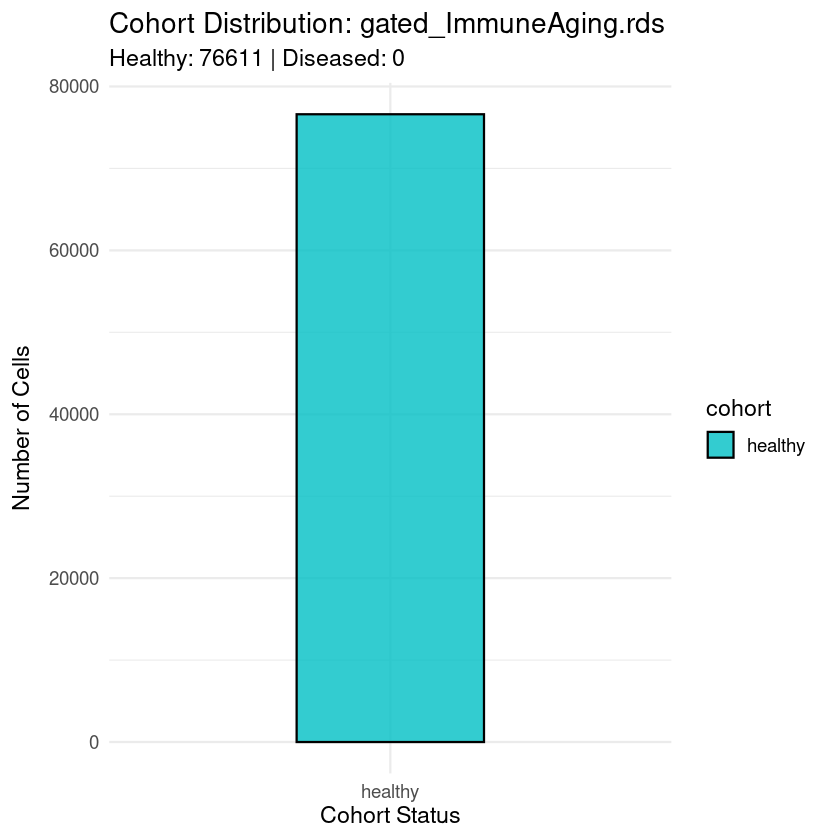

In [52]:
# PLOT 1: Cohort distribution
p1 <- ggplot(metadata, aes(x = cohort, fill = cohort)) +
  geom_bar(alpha = 0.8, color = "black", width = 0.4) +
  scale_fill_manual(values = c("healthy" = "#00bfc4", "diseased" = "#f8766d")) +
  theme_minimal(base_size = 14) +
  labs(
    title = paste("Cohort Distribution:", file_name),
    subtitle = paste("Healthy:", sum(metadata$cohort == "healthy"), "| Diseased:", sum(metadata$cohort == "diseased")),
    x = "Cohort Status", y = "Number of Cells"
  )
print(p1)
ggsave(paste0(output_dir, "cohort_dist_", clean_name, ".png"), plot = p1, width = 6, height = 5, dpi = 300)

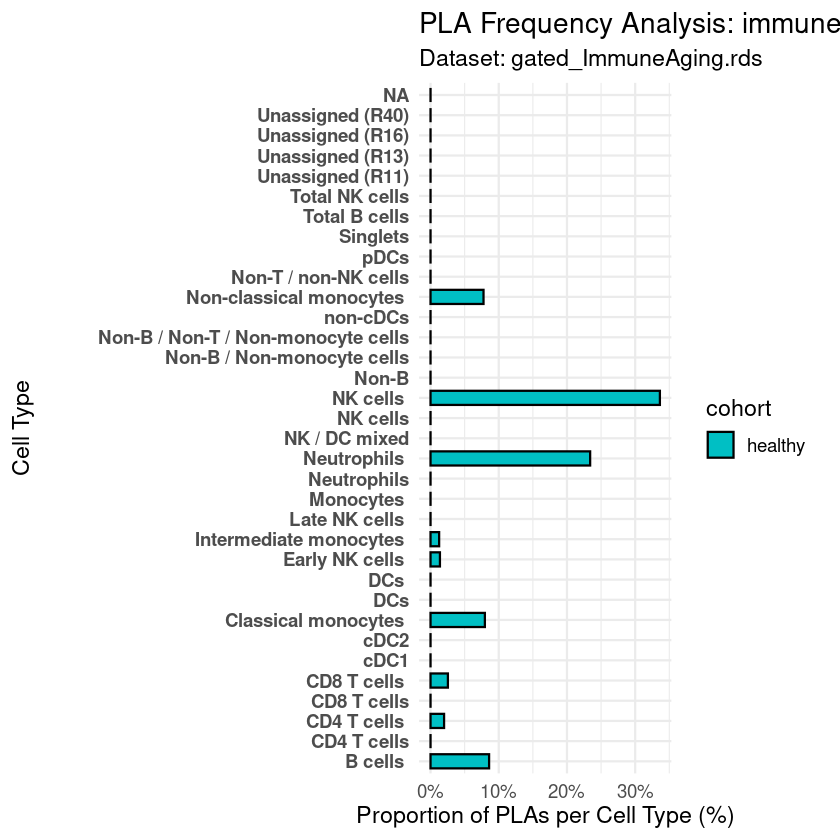

In [53]:
# PLOT 2: PLA frequency per celltype
if (!is.na(cell_col) & !is.na(pla_col)) {
  pla_freq <- metadata %>%
    group_by(!!sym(cell_col), cohort) %>%
    summarise(
      PLA_rate = sum(tolower(!!sym(pla_col)) == "pla", na.rm = TRUE) / n(),
      .groups = "drop"
    )
  
  p2 <- ggplot(pla_freq, aes(y = !!sym(cell_col), x = PLA_rate, fill = cohort)) +
    geom_bar(stat = "identity", position = "dodge", color = "black", width = 0.7) +
    scale_x_continuous(labels = scales::percent_format()) +
    scale_fill_manual(values = c("healthy" = "#00bfc4", "diseased" = "#f8766d")) +
    theme_minimal(base_size = 14) +
    theme(axis.text.y = element_text(face = "bold")) +
    labs(
      title = paste("PLA Frequency Analysis:", dataset_type),
      subtitle = paste("Dataset:", file_name),
      x = "Proportion of PLAs per Cell Type (%)", y = "Cell Type"
    )
  print(p2)
  ggsave(paste0(output_dir, "pla_frequency_", clean_name, ".png"), plot = p2, width = 11, height = 7, dpi = 300)
} else {
  print("PLA or Celltype not found")
}

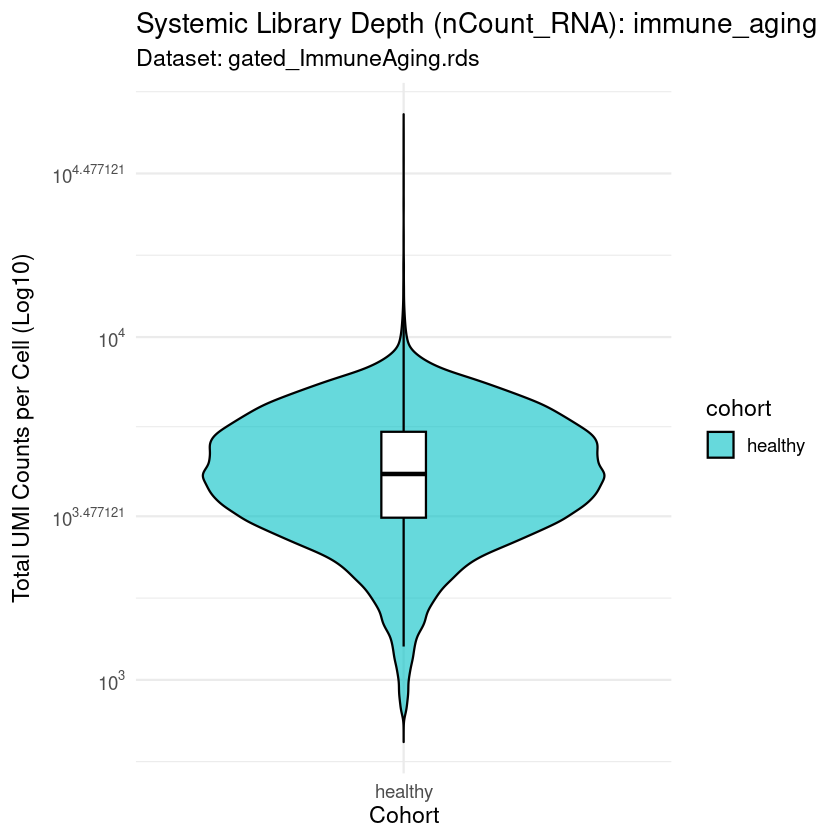

In [54]:
# PLOT 3: Sequencing depth
if ("nCount_RNA" %in% colnames(metadata)) {
  p3 <- ggplot(metadata, aes(x = cohort, y = nCount_RNA, fill = cohort)) +
    geom_violin(alpha = 0.6, trim = FALSE, color = "black") +
    geom_boxplot(width = 0.1, fill = "white", outlier.shape = NA, color = "black") +
    scale_y_log10(labels = scales::trans_format("log10", scales::math_format(10^.x))) +
    scale_fill_manual(values = c("healthy" = "#00bfc4", "diseased" = "#f8766d")) +
    theme_minimal(base_size = 14) +
    labs(
      title = paste("Systemic Library Depth (nCount_RNA):", dataset_type),
      subtitle = paste("Dataset:", file_name),
      x = "Cohort", y = "Total UMI Counts per Cell (Log10)"
    )
  print(p3)
  ggsave(paste0(output_dir, "library_depth_", clean_name, ".png"), plot = p3, width = 7, height = 5, dpi = 300)
}

Warning message:
“NAs introduced by coercion”


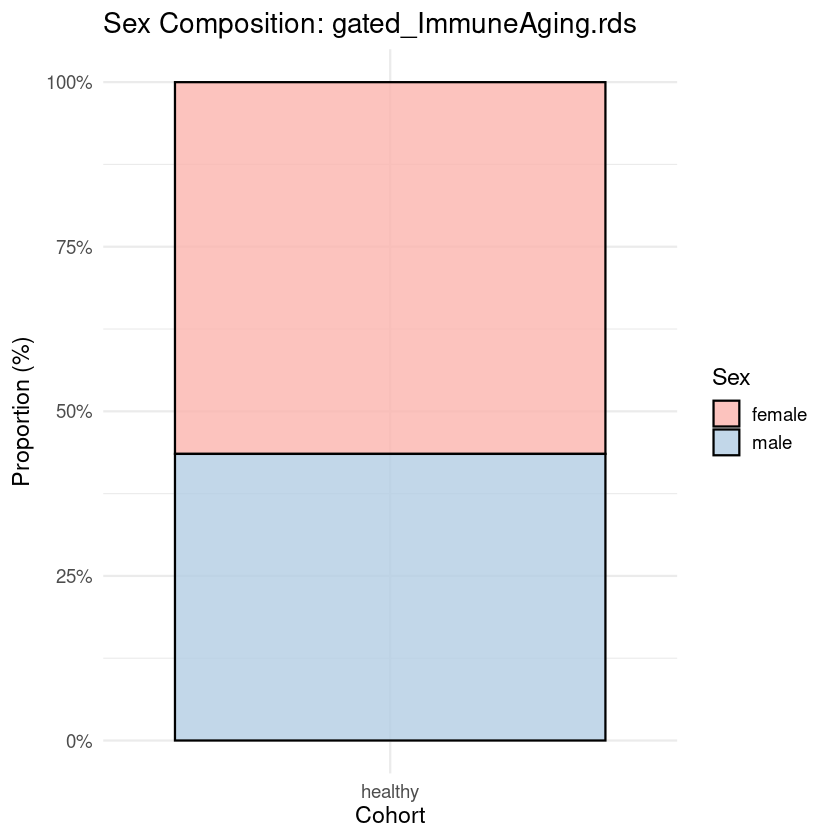

In [57]:
# Demography exploration
if ("Age" %in% colnames(metadata)) { 
    metadata$Explor_Age <- as.numeric(metadata$Age) 
} else if ("donor_age" %in% colnames(metadata)) { 
    metadata$Explor_Age <- as.numeric(metadata$donor_age) 
} else { 
    metadata$Explor_Age <- NA 
}

if ("Sex" %in% colnames(metadata)) { 
    metadata$Explor_Sex <- as.character(metadata$Sex) 
} else if ("Gender" %in% colnames(metadata)) { 
    metadata$Explor_Sex <- as.character(metadata$Gender) 
} else if ("sex" %in% colnames(metadata)) { 
    metadata$Explor_Sex <- as.character(metadata$sex) 
} else { 
    metadata$Explor_Sex <- NA 
}

if (!all(is.na(metadata$Explor_Age))) {
  p_age <- ggplot(metadata, aes(x = cohort, y = Explor_Age, fill = cohort)) +
    geom_boxplot(alpha = 0.7, outlier.shape = 16, outlier.size = 1) +
    scale_fill_manual(values = c("healthy" = "#00bfc4", "diseased" = "#f8766d")) +
    theme_minimal(base_size = 14) +
    labs(title = paste("Age Distribution:", file_name), x = "Cohort", y = "Age (Years)")
  print(p_age)
  ggsave(paste0(output_dir, "demo_age_", clean_name, ".png"), plot = p_age, width = 5, height = 5, dpi = 300)
}

if (!all(is.na(metadata$Explor_Sex))) {
  p_sex <- ggplot(metadata, aes(x = cohort, fill = Explor_Sex)) +
    geom_bar(position = "fill", color = "black", alpha = 0.8) +
    scale_y_continuous(labels = scales::percent_format()) +
    scale_fill_brewer(palette = "Pastel1") +
    theme_minimal(base_size = 14) +
    labs(title = paste("Sex Composition:", file_name), x = "Cohort", y = "Proportion (%)", fill = "Sex")
  print(p_sex)
  ggsave(paste0(output_dir, "demo_sex_", clean_name, ".png"), plot = p_sex, width = 5, height = 5, dpi = 300)
}

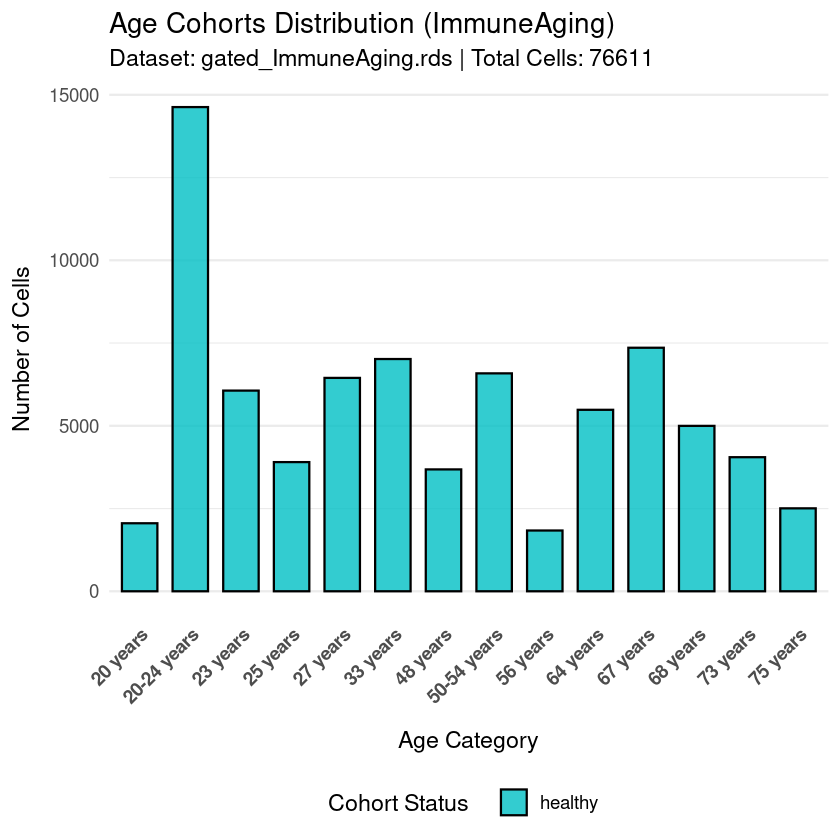

In [61]:
if ("donor_age" %in% colnames(metadata)) {
  
  metadata_clean <- metadata %>% filter(!is.na(donor_age) & donor_age != "unknown")
 
  metadata_clean$donor_age <- factor(metadata_clean$donor_age, 
                                   levels = sort(unique(metadata_clean$donor_age)))

  p_age <- ggplot(metadata_clean, aes(x = donor_age, fill = cohort)) +
  geom_bar(position = "dodge", color = "black", alpha = 0.8, width = 0.7) +
  scale_fill_manual(values = c("healthy" = "#00bfc4", "diseased" = "#f8766d")) +
  theme_minimal(base_size = 14) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, face = "bold"), # Schräge Schrift für perfekte Lesbarkeit
    panel.grid.major.x = element_blank(),
    legend.position = "bottom"
  ) +
  labs(
    title = "Age Cohorts Distribution (ImmuneAging)",
    subtitle = paste("Dataset:", file_name, "| Total Cells:", nrow(metadata_clean)),
    x = "Age Category", 
    y = "Number of Cells",
    fill = "Cohort Status"
  )
  
  print(p_age)
  ggsave(paste0(output_dir, "demo_age_categories_", clean_name, ".png"), plot = p_age, width = 8, height = 5, dpi = 300)
} else {
  print(paste("Keine Altersdaten im Datensatz", file_name, "verfügbar."))
}

In [62]:
# Special plots
if (dataset_type == "our_data" & "condition_all" %in% colnames(metadata)) {
  
  kinetic_data <- metadata %>%
    filter(str_detect(condition_all, "MI|Healthy")) %>%
    group_by(condition_all) %>%
    summarise(PLA_rate = sum(tolower(!!sym(pla_col)) == "pla", na.rm = TRUE) / n(), .groups = "drop")
  
  p_spec <- ggplot(kinetic_data, aes(x = condition_all, y = PLA_rate, fill = condition_all)) +
    geom_bar(stat = "identity", color = "black", alpha = 0.8, width = 0.6) +
    scale_y_continuous(labels = scales::percent_format()) +
    theme_minimal(base_size = 14) +
    theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
    labs(title = "Eigene Daten: PLA-Verlauf nach Herzinfarkt", x = "Zeitpunkt / Zustand", y = "Globale PLA-Rate (%)")
  print(p_spec)
  ggsave(paste0(output_dir, "spec_kinetics_", clean_name, ".png"), plot = p_spec, width = 7, height = 5, dpi = 300)

} else if (dataset_type == "sepsis" & "SOFA.score" %in% colnames(metadata)) {
  
  sepsis_data <- metadata %>%
    mutate(SOFA_Group = case_when(SOFA.score <= 5 ~ "Mild (0-5)", SOFA.score <= 10 ~ "Moderate (6-10)", TRUE ~ "Severe (11+)")) %>%
    filter(!is.na(SOFA.score))
  
  p_spec <- ggplot(sepsis_data, aes(x = SOFA_Group, y = nCount_RNA, fill = SOFA_Group)) +
    geom_violin(alpha = 0.7, trim = FALSE) +
    geom_boxplot(width = 0.1, fill = "white", outlier.shape = NA) +
    scale_y_log10(labels = scales::trans_format("log10", scales::math_format(10^.x))) +
    scale_fill_brewer(palette = "Oranges") +
    theme_minimal(base_size = 14) +
    labs(title = "Sepsis: Library Depth vs. Organ Failure (SOFA)", x = "SOFA Severity Group", y = "nCount_RNA (Log10)")
  print(p_spec)
  ggsave(paste0(output_dir, "spec_sofa_", clean_name, ".png"), plot = p_spec, width = 7, height = 5, dpi = 300)

} else if (dataset_type == "vaccine" & "Phase" %in% colnames(metadata)) {
  
  p_spec <- ggplot(metadata, aes(x = as.factor(time), fill = Phase)) +
    geom_bar(position = "fill", color = "black", alpha = 0.8, width = 0.6) +
    scale_y_continuous(labels = scales::percent_format()) +
    scale_fill_brewer(palette = "Set2") +
    theme_minimal(base_size = 14) +
    labs(title = "Vaccine: Cell Cycle Shift after Vaccination", x = "Days post Vaccination", y = "Proportion of Cells (%)", fill = "Cell Cycle Phase")
  print(p_spec)
  ggsave(paste0(output_dir, "spec_cellcycle_", clean_name, ".png"), plot = p_spec, width = 6, height = 5, dpi = 300)

} else if (dataset_type == "heart" & "HF.etiology" %in% colnames(metadata)) {
  
  p_spec <- ggplot(metadata, aes(x = HF.etiology, y = nCount_RNA, fill = HF.etiology)) +
    geom_boxplot(alpha = 0.7, outlier.shape = 16, outlier.size = 0.5) +
    scale_y_log10(labels = scales::trans_format("log10", scales::math_format(10^.x))) +
    theme_minimal(base_size = 14) +
    labs(title = "Heart: Library Depth Across All Etiologies", x = "Detailed Etiology", y = "nCount_RNA (Log10)") +
    theme(legend.position = "none")
  print(p_spec)
  ggsave(paste0(output_dir, "spec_etiologies_", clean_name, ".png"), plot = p_spec, width = 7, height = 5, dpi = 300)
}

In [58]:
table(metadata$donor_age)


   20 years 20-24 years    23 years    25 years    27 years    33 years 
       2055       14629        6063        3903        6447        7017 
   48 years 50-54 years    56 years    64 years    67 years    68 years 
       3682        6584        1836        5483        7358        4997 
   73 years    75 years 
       4051        2506 